In [28]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

BASEFOLDER = "RealWaste/" 
CATEGORIES = ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash']

HOG_IMG_HEIGHT = 128
HOG_IMG_WIDTH = 64
HOG_TARGET_SIZE = (HOG_IMG_WIDTH, HOG_IMG_HEIGHT)

RANDOM_STATE = 42

In [30]:

# Get File Paths and Labels ---
labels_map = {cat: index for index, cat in enumerate(CATEGORIES)} 

all_image_filepaths_ml = []
all_image_labels_ml = []

basefolder = "RealWaste/" 

for index, cat_name in enumerate(CATEGORIES):
    sub_directory = os.path.join(BASEFOLDER, cat_name)
    if not os.path.isdir(sub_directory):
        print(f"Warning: Directory '{sub_directory}' for category '{cat_name}' not found. Skipping.")
        continue
    
    try:
        image_filenames = os.listdir(sub_directory)
        for image_filename in image_filenames:
            if image_filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
                full_image_path = os.path.join(sub_directory, image_filename)
                all_image_filepaths_ml.append(full_image_path)
                all_image_labels_ml.append(labels_map[cat_name])

    except OSError as e:
        print(f"Error listing files in '{sub_directory}': {e}. Skipping.")

# Convert to NumPy arrays for easier handling with train_test_split
all_image_filepaths_ml = np.array(all_image_filepaths_ml)
all_image_labels_ml = np.array(all_image_labels_ml)

print(f"Total image paths found: {len(all_image_filepaths_ml)}")
print(f"Total labels found: {len(all_image_labels_ml)}")

Total image paths found: 4316
Total labels found: 4316


In [31]:
X_train_paths_ml, X_test_paths_ml, Y_train_ml, Y_test_ml = train_test_split(
    all_image_filepaths_ml,
    all_image_labels_ml,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=all_image_labels_ml 
)

print(f"Number of training image paths: {len(X_train_paths_ml)}")
print(f"Number of training labels: {len(Y_train_ml)}")
print(f"Number of testing image paths: {len(X_test_paths_ml)}")
print(f"Number of testing labels: {len(Y_test_ml)}")

Number of training image paths: 3237
Number of training labels: 3237
Number of testing image paths: 1079
Number of testing labels: 1079


In [33]:
def extract_hog_features(image_path, target_size=(64, 128)): 
    #we are reading the image
    img = cv2.imread(image_path)

    #we are converting the image into grayscale and resizing for feeding image in HOG Descriptor
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    resized_img = cv2.resize(gray_img, target_size, interpolation=cv2.INTER_AREA)
    
    # HOG Descriptor parameters
    win_size = target_size 
    cell_size = (8, 8)
    block_size_in_cells = (2, 2)
    
    block_size_pixels = (block_size_in_cells[0] * cell_size[0], block_size_in_cells[1] * cell_size[1])
    block_stride = (cell_size[0], cell_size[1]) 
    nbins = 9 

    hog = cv2.HOGDescriptor(win_size, block_size_pixels, block_stride, cell_size, nbins)
    
    hog_descriptor = hog.compute(resized_img)
    
    if hog_descriptor is not None:
        return hog_descriptor.flatten()
    else:
        print(f"Warning: HOG descriptor was None for {image_path}")
        return None


In [34]:
def process_paths_to_features(filepaths_list, corresponding_labels, feature_extraction_func, target_size_for_features):
    extracted_features = []
    valid_labels_for_features = []
    
    for i, path in enumerate(filepaths_list):
        features = feature_extraction_func(path, target_size=target_size_for_features)
        if features is not None:
            extracted_features.append(features)
            valid_labels_for_features.append(corresponding_labels[i])
        else: print(f"Skipping image {path} as features could not be extracted.")
            
    return np.array(extracted_features), np.array(valid_labels_for_features)


# Extract HOG features for the training set
X_train_hog, Y_train_hog_valid = process_paths_to_features(X_train_paths_ml, Y_train_ml, extract_hog_features, HOG_TARGET_SIZE)
print(f"\nTraining HOG features shape: {X_train_hog.shape}")
print(f"Valid training labels shape: {Y_train_hog_valid.shape}")

# Extract HOG features for the testing set
X_test_hog, Y_test_hog_valid = process_paths_to_features(X_test_paths_ml, Y_test_ml, extract_hog_features, HOG_TARGET_SIZE)
print(f"\nTest HOG features shape: {X_test_hog.shape}")
print(f"Valid test labels shape: {Y_test_hog_valid.shape}")


Training HOG features shape: (3237, 3780)
Valid training labels shape: (3237,)

Test HOG features shape: (1079, 3780)
Valid test labels shape: (1079,)


In [38]:
def scaling(training_X,testing_X):
    if training_X.shape[0] > 0 and testing_X.shape[0] > 0:
        print("\nScaling HOG features")
        scaler= StandardScaler()
        X_train_scaled = scaler.fit_transform(training_X)
        X_test_scaled = scaler.transform(testing_X)

        print("Features scaled.")
        print(f"X_train_scaled shape: {X_train_scaled.shape}")
        print(f"X_test_scaled shape: {X_test_scaled.shape}")
        return X_train_scaled,X_test_scaled
    else:
        return None
    
X_train_scaled,X_test_scaled =scaling(X_train_hog,X_test_hog)


Scaling HOG features
Features scaled.
X_train_scaled shape: (3237, 3780)
X_test_scaled shape: (1079, 3780)


In [40]:
#Training Model
def train_predict_model(X_train_scaled,X_test_scaled,Y_train):
    print("\nTraining the model")

    svc_model = SVC(kernel='rbf', C=1.0, probability=False, random_state=RANDOM_STATE)
    rf_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)

    svc_model.fit(X_train_scaled, Y_train)
    rf_model.fit(X_train_scaled, Y_train)

    print("Model training complete.")

    Y_pred_svc_ml = svc_model.predict(X_test_scaled)
    Y_pred_rf_ml = rf_model.predict(X_test_scaled)

    return Y_pred_svc_ml,Y_pred_rf_ml

Y_pred_svc_ml,Y_pred_rf_ml = train_predict_model(X_train_scaled,X_test_scaled ,Y_train_hog_valid)


Training the model
Model training complete.



Evaluating Model SVC
                     precision    recall  f1-score   support

          Cardboard       0.67      0.70      0.68       115
      Food Organics       0.59      0.68      0.63       103
              Glass       0.82      0.52      0.64       105
              Metal       0.53      0.57      0.55       197
Miscellaneous Trash       0.44      0.17      0.24       124
              Paper       0.56      0.42      0.48       125
            Plastic       0.44      0.75      0.56       230
      Textile Trash       0.48      0.19      0.27        80

           accuracy                           0.54      1079
          macro avg       0.57      0.50      0.51      1079
       weighted avg       0.55      0.54      0.52      1079



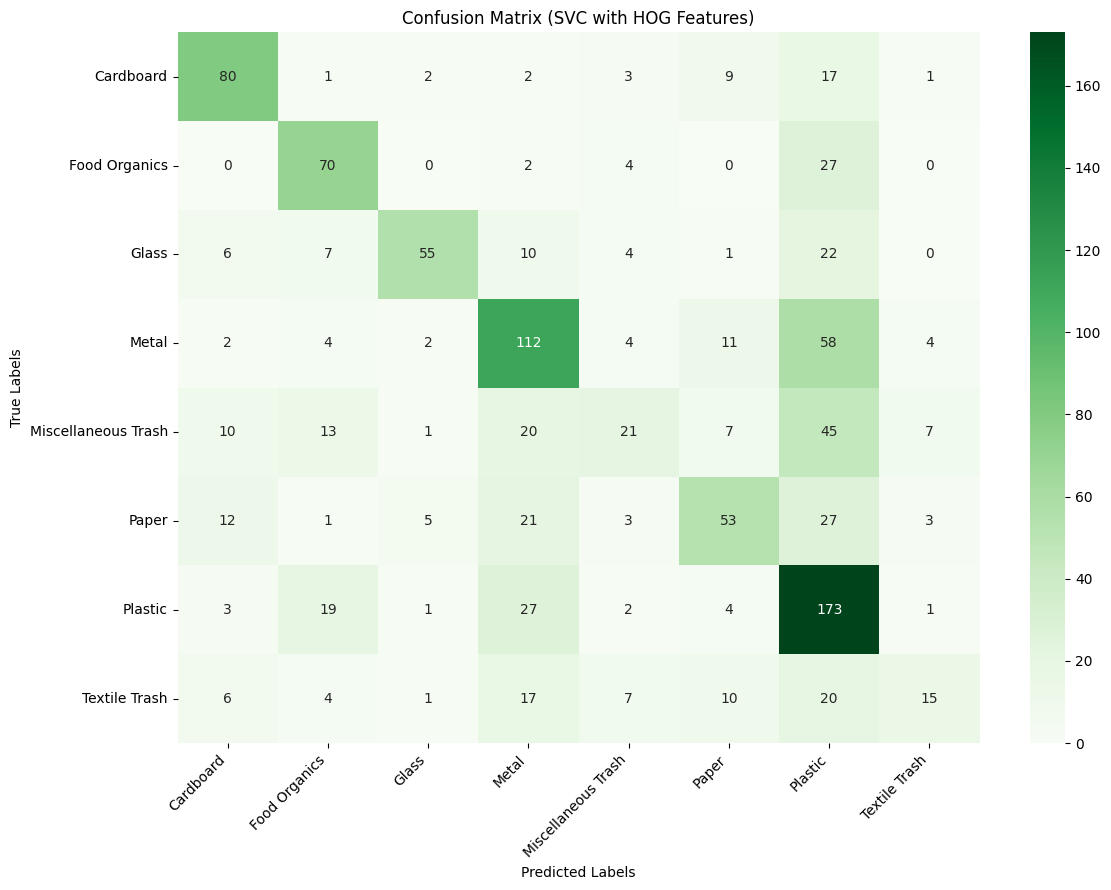


Evaluating Model Random Forest
                     precision    recall  f1-score   support

          Cardboard       0.70      0.71      0.71       115
      Food Organics       0.53      0.41      0.46       103
              Glass       0.64      0.32      0.43       105
              Metal       0.40      0.49      0.44       197
Miscellaneous Trash       0.44      0.09      0.15       124
              Paper       0.51      0.28      0.36       125
            Plastic       0.37      0.80      0.51       230
      Textile Trash       0.40      0.03      0.05        80

           accuracy                           0.45      1079
          macro avg       0.50      0.39      0.39      1079
       weighted avg       0.48      0.45      0.41      1079



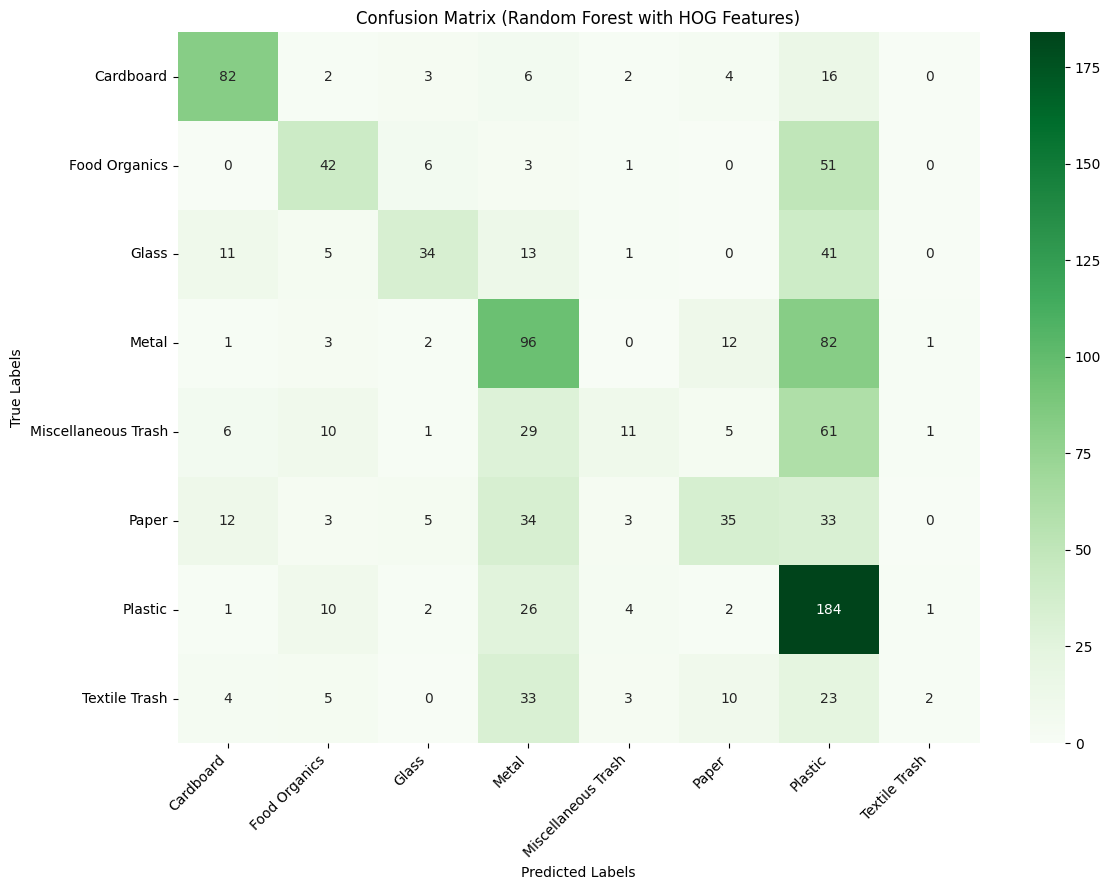

In [41]:
#Evaluation Metrics
def evaluate_model(predicted_Y,true_Y,modelname):

    print(f"\nEvaluating Model {modelname}")
    # Use Categories for target_names  to display each scores 
    print(classification_report(true_Y, predicted_Y, target_names=CATEGORIES, zero_division=0))
    cm_ml = confusion_matrix(true_Y, predicted_Y)

    plt.figure(figsize=(12, 9)) # Adjusted size for better label visibility
    sns.heatmap(cm_ml, annot=True, fmt='d', cmap='Greens', xticklabels=CATEGORIES, yticklabels=CATEGORIES)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title(f'Confusion Matrix ({modelname} with HOG Features)')
    plt.xticks(rotation=45, ha='right') 
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

evaluate_model(Y_pred_svc_ml,Y_test_hog_valid,"SVC")
evaluate_model(Y_pred_rf_ml,Y_test_hog_valid,"Random Forest")